# 04 · How to read PR-AUC & ROC-AUC at this imbalance
A score is only meaningful against the right baseline. PR-AUC baseline = test prevalence (0.0403); ROC-AUC baseline = 0.5. We express every model as **×-lift** and a coarse verdict.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().resolve().parents[1]  # notebooks/ -> 02_cv_strategies/
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd
from IPython.display import HTML, display
from cv_strategies import config as C, evaluation_ext as E, report as R
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('session folder:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
base = E.baseline(); print('baseline', round(base,4))
rows=[]
for r in json.loads(C.IMBALANCE_JSON.read_text())['session1_lift']:
    rows.append({'model':r['model'],'pr_auc':r['pr_auc'],'x_lift':r['pr_auc']/base,
                 'verdict':E.pr_verdict(r['pr_auc']),'roc_auc':r['roc_auc'],
                 'roc_verdict':E.roc_verdict(r['roc_auc'])})
pd.DataFrame(rows)

baseline 0.0403


,model,pr_auc,x_lift,verdict,roc_auc,roc_verdict
0,CatBoost,0.0795,1.9741,weak (1.2-2x),0.6078,weak
1,LightGBM,0.0793,1.9699,weak (1.2-2x),0.6178,weak
2,HistGradientBoostingClassifier,0.0752,1.8688,weak (1.2-2x),0.6197,weak
3,EasyEnsembleClassifier,0.0704,1.7499,weak (1.2-2x),0.5659,poor (~random)
4,LogisticRegression,0.0626,1.5542,weak (1.2-2x),0.5773,poor (~random)
5,XGBoost,0.0595,1.4777,weak (1.2-2x),0.6031,weak
6,ExtraTreesClassifier,0.0582,1.4452,weak (1.2-2x),0.5776,poor (~random)
7,SGDClassifier,0.0574,1.4270,weak (1.2-2x),0.5589,poor (~random)
8,GaussianNB,0.0572,1.4211,weak (1.2-2x),0.6203,weak
9,BalancedRandomForestClassifier,0.0570,1.4150,weak (1.2-2x),0.6017,weak


### Best tuned model — PR and ROC curves with baseline references


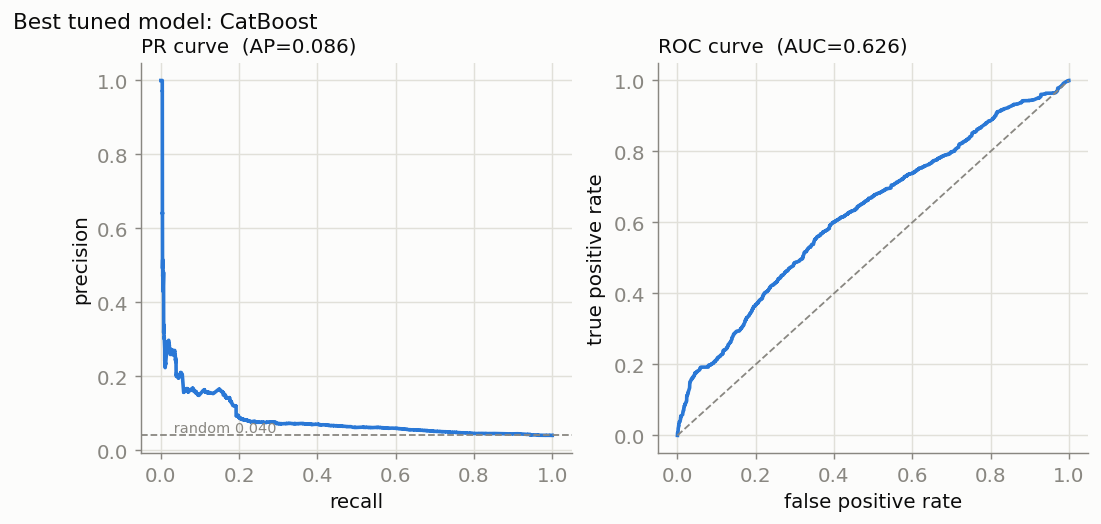

In [3]:
t = pd.read_csv(C.TUNING_RESULTS_CSV); t=t[t['status']=='ok'].sort_values('test_pr_auc',ascending=False)
best=t.iloc[0]['model']; proba=np.load(C.GRID_DIR/f'{best}_tuned_test_proba.npy')
y=np.load(C.frozen_artifact_path('y_test'))
display(HTML(f'<img src="{R.fig_pr_roc(y, proba, base, best)}">'))

### Why our numbers look lower than Skrzeczek's (0.98 ROC-AUC) — and why that is expected
Skrzeczek classifies **whole jobs** (aggregated), on ~920 jobs at ~2.6:1 imbalance, with the **successful** job as the positive class, reporting accuracy/F1/ROC-AUC. Ours is **per-window, extreme-imbalance, early** prediction of the **rare failure** — harder by construction. PR-AUC against the 0.0403 baseline is the honest yardstick. See `docs/session_2_methodology.md` §9.